## **Multiple Linear Regression Model**

#### **Let's mimic the process of building our trading model of SPY, base on the historical data of different stock markets**

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
# import all stock market data into DataFrame
aord = pd.read_csv('data/indice/ALLOrdinary.csv')
nikkei = pd.read_csv('data/indice/Nikkei225.csv')
hsi = pd.read_csv('data/indice/HSI.csv')
daxi = pd.read_csv('data/indice/DAXI.csv')
cac40 = pd.read_csv('data/indice/CAC40.csv')
sp500 = pd.read_csv('data/indice/SP500.csv')
dji = pd.read_csv('data/indice/DJI.csv')
nasdaq = pd.read_csv('data/indice/nasdaq_composite.csv')
spy = pd.read_csv('data/indice/SPY.csv')

In [6]:
nasdaq.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2008-01-02,2653.909912,2661.500000,2597.810059,2609.629883,2609.629883,2076690000
1,2008-01-03,2611.959961,2624.270020,2592.179932,2602.679932,2602.679932,1970200000
2,2008-01-04,2571.080078,2571.080078,2502.679932,2504.649902,2504.649902,2516310000
3,2008-01-07,2514.149902,2521.620117,2471.229980,2499.459961,2499.459961,2600100000
4,2008-01-08,2506.969971,2527.419922,2440.510010,2440.510010,2440.510010,2566480000


### **Step 1: Data Munging**

In [10]:
# Due to the timezone issues, we extract and calculate appropriate stock market data for analysis
# Indicepanel is the DataFrame of our trading model
indicepanel = pd.DataFrame(index=spy.index)

indicepanel['spy'] = spy['Open'].shift(-1) - spy['Open']
indicepanel['spy_lag1'] = indicepanel['spy'].shift(1)
indicepanel['sp500'] = sp500['Open'] - sp500['Open'].shift(1)
indicepanel['nasdaq'] = nasdaq['Open'] - nasdaq['Open'].shift(1)
indicepanel['dji'] = dji['Open'] - dji['Open'].shift(1)
indicepanel['cac40'] = cac40['Open'] - cac40['Open'].shift(1)
indicepanel['daxi'] = daxi['Open'] - daxi['Open'].shift(1)
indicepanel['aord'] = aord['Open'] - aord['Open'].shift(1)
indicepanel['hsi'] = hsi['Open'] - hsi['Open'].shift(1)
indicepanel['nikkei'] = nikkei['Open'] - nikkei['Open'].shift(1)
indicepanel['Price'] = spy['Open']

In [11]:
indicepanel.head()

,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
0,-1.619995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146.529999
1,-1.570008,-1.619995,-20.419922,-41.949951,-217.70019,-71.779785,-104.450195,4.100097,-582.169922,-606.350586,144.910004
2,-1.529998,-1.570008,-3.540039,-40.879883,2.43945,5.489746,-27.990235,-35.000000,-45.689453,-120.080078,143.339996
3,0.270004,-1.529998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-29.900390,-41.800781,-64.589844,141.809998
4,-2.990006,0.270004,1.640015,-7.179931,19.75000,44.509766,33.680176,-124.599610,504.421875,181.610352,142.080002


In [12]:
# Lets check whether do we have NaN values in indicepanel
indicepanel.isnull().sum()

spy          1
spy_lag1     1
sp500        1
nasdaq       1
dji          1
cac40        3
daxi        11
aord         5
hsi         65
nikkei      58
Price        0
dtype: int64

In [14]:
# We can use method 'fillna()' from dataframe to forward filling the Nan values
# Then we can drop the reminding Nan values
indicepanel = indicepanel.ffill()
indicepanel = indicepanel.dropna()

In [15]:
# Lets check whether do we have Nan values in indicepanel now
indicepanel.isnull().sum()

spy         0
spy_lag1    0
sp500       0
nasdaq      0
dji         0
cac40       0
daxi        0
aord        0
hsi         0
nikkei      0
Price       0
dtype: int64

In [16]:
# save this indicepanel
path_save = 'data/indice/indicepanel.csv'
indicepanel.to_csv(path_save)

In [17]:
print(indicepanel.shape)

(2678, 11)


### **Step 2: Data Splitting**

In [18]:
# split the data into 1) train set and 2) test set
Train = indicepanel.iloc[-2000:-1000, :]
Test = indicepanel.iloc[-1000:, :]
print(Train.shape, Test.shape)

(1000, 11) (1000, 11)


### **Step 3: Explore the Train Dataset**

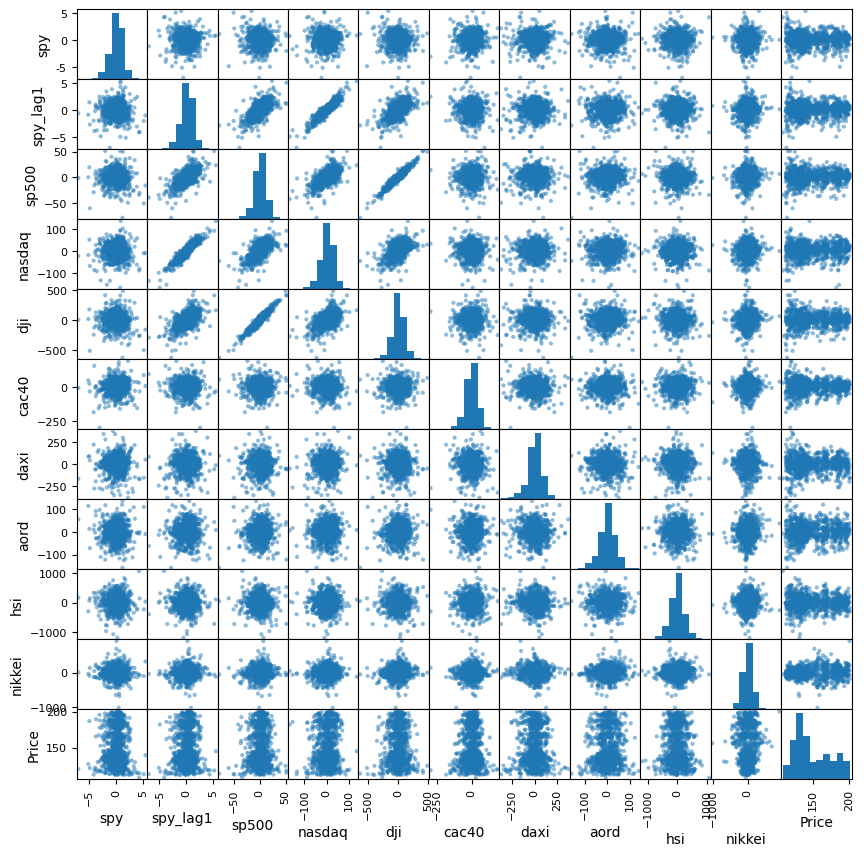

In [20]:
# Generate scatter matrix among all stock markets (and the price of SPY) to observe the association
from pandas.plotting import scatter_matrix
sm = scatter_matrix(Train, figsize=(10,10))

### **Step 4: Check the Correlation of each index between SPY**

In [21]:
# Find the indice with largest correlation
corr_array = Train.iloc[:, :-1].corr()['spy']
print(corr_array)

spy         1.000000
spy_lag1   -0.011623
sp500      -0.018632
nasdaq      0.012333
dji        -0.037097
cac40       0.076886
daxi        0.019410
aord       -0.003211
hsi        -0.006059
nikkei      0.017621
Name: spy, dtype: float64


In [22]:
formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'
lm = smf.ols(formula=formula, data=Train).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.531
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.132
Time:                        18:17:56   Log-Likelihood:                -1645.8
No. Observations:                1000   AIC:                             3312.
Df Residuals:                     990   BIC:                             3361.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0842      0.040      2.101      0.036       0.006       0.163
spy_lag1      -0.1229      0.092     -1.333      0.183      -0.304       0.058
sp500          0.0195      0.014      1.390      0.165      -0.008       0.047
nasdaq         0.0046      0.004      1.202      0.230      -0.003       0.012
dji           -0.0024      0.001     -1.672      0.095      -0.005       0.000
cac40          0.0021      0.001      2.372      0.018       0.000       0.004
aord          -0.0002      0.001     -0.176      0.860      -0.002       0.002
daxi           0.0003      0.000      0.556      0.578      -0.001       0.001
nikkei         0.0002      0.000      0.653      0.514      -0.000       0.001
hsi        -4.672e-05      0.000     -0.287      0.775      -0.000       0.000
==============================================================================
Omnibus:                       88.021   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              247.690
Skew:                          -0.448   Prob(JB):                     1.64e-54
Kurtosis:                       5.268   Cond. No.                         568.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Step 5: Make Prediction**

In [23]:
Train['PredictedY'] = lm.predict(Train)
Test['PredictedY'] = lm.predict(Test)

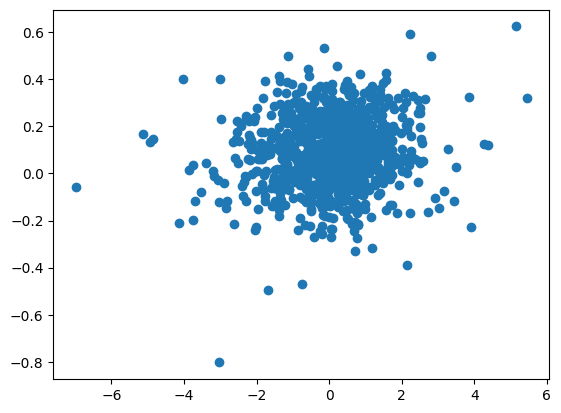

In [24]:
plt.scatter(Train['spy'], Train['PredictedY'])

### **Step 6: Model Evaluation - Statistical Standard**

We can measure the performance of our model using some statistical metrics - **RMSE**, **Adjusted $R^2$**

In [29]:
# RMSE - Root Mean Squared Error, Adjusted R^2
def adjustedMetric(data, model,model_k, yname):
    data['yhat'] = model.predict(data)
    SST = ((data[yname] - data[yname].mean())**2).sum()
    SSR = ((data['yhat'] - data[yname].mean())**2).sum()
    SSE = ((data[yname] - data['yhat'])**2).sum()
    r2 = SSR/SST
    adjustR2 = 1 - (1-r2)*(data.shape[0] - 1)/(data.shape[0] - model_k - 1)
    RMSE = (SSE/(data.shape[0] - model_k -1))**0.5
    return adjustR2, RMSE

In [32]:
def assessTable(test, train, model, model_k, yname):
    r2test, RMSEtest = adjustedMetric(test, model, model_k, yname)
    r2train, RMSEtrain = adjustedMetric(train, model, model_k, yname)
    assessment = pd.DataFrame(index=['R2', 'RMSE'], columns=['Train', 'Test'])
    assessment['Train'] = [r2train, RMSEtrain]
    assessment['Test'] = [r2test, RMSEtest]
    return assessment

In [33]:
# Get the assessment table for our model
assessTable(Test, Train, lm, 9, 'spy')

,Train,Test
R2,0.004764,0.008404
RMSE,1.260920,1.762769
